## Empirical Benchmarking

Let's compare a few algorithms for summing the first k numbers. This is expanded from an example in the book.

In [18]:
from time import time           # for measuring execution time using time()
from time import perf_counter   # for measuring execution time with higher precision

import pandas as pd
import seaborn as sns           # for creating visualizations
import matplotlib.pyplot as plt # for modifying visualizations

In [8]:
# sum the first k numbers
def sumFirstK(k):
    total = 0
    for i in range(1, k+1):
        total += i
    return total

# less efficient way to sum the first k numbers using double loop
def sumFirstK_slow(k):
    total = 0
    for i in range(1, k+1):
        counter = 0
        for j in range(1, i+1):
            counter += 1
        total += i
    return total

Now, let's compare these algorithms empirically by measuring their execution time. The good news is that inputs to the algorithms are simply the value of $k$, so we can easily vary it and observe how the execution time changes.

In [35]:
# Function to benchmark the execution time of a given algorithm over a set of test cases

def benchmark_algo(algo, test_cases):
    times = []
    for i in test_cases:
        start = perf_counter()
        algo(i)
        end = perf_counter()
        times.append((i, end - start))
    return times


def benchmark_algo_multi(algo, test_cases, repeat=1):
    times = []
    for i in test_cases:
        for _ in range(repeat):
            start = perf_counter()
            algo(i)
            end = perf_counter()
            times.append((i, end - start))
    return times

In [47]:
test_cases = range(1, 5000, 10)
sumFirstK_times = benchmark_algo(sumFirstK, test_cases)


In [48]:
# putting our results in a data frame

df_base = pd.DataFrame(sumFirstK_times, columns = ["k", "time"])
df_base['algo'] = "sumFirstK"


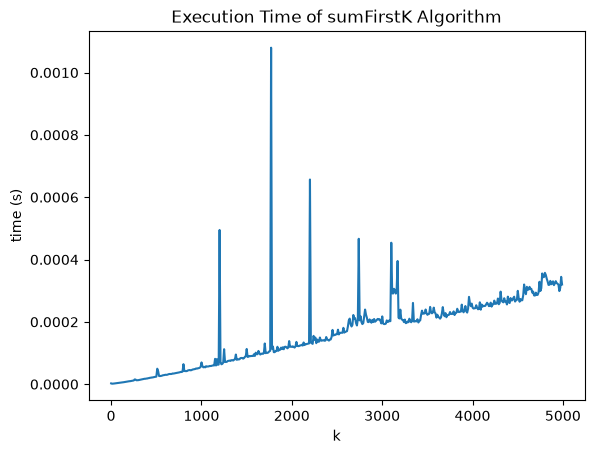

In [49]:
# Let's look at the execution time of the sumFirstK algorithm

sns.lineplot(data=df_base, x="k", y="time")
plt.xlabel("k")
plt.ylabel("time (s)")
plt.title("Execution Time of sumFirstK Algorithm")
plt.show()

We can make two observations:
1. The execution time of the `sumFirstK` algorithm increases linearly with `k`.
2. There are random fluctuations in the execution time due to system load and other factors.

We can address the second by running multiple trials and averaging the results. Seaborn makes it easy to visualize this by plotting the mean execution time with confidence intervals. The `benchmark_algo_multi` function can be used to collect multiple measurements for each test case.

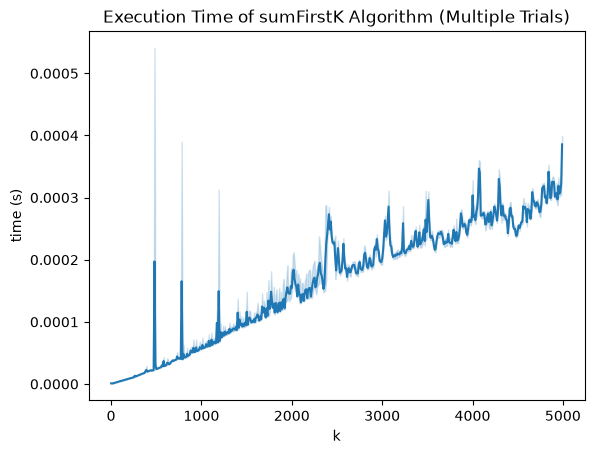

In [50]:
sumFirstK_times_multi = benchmark_algo_multi(sumFirstK, test_cases, repeat=5)
df_base_multi = pd.DataFrame(sumFirstK_times_multi, columns = ["k", "time"])
df_base_multi['algo'] = "sumFirstK"

sns.lineplot(data=df_base_multi, x="k", y="time")
plt.xlabel("k")
plt.ylabel("time (s)")
plt.title("Execution Time of sumFirstK Algorithm (Multiple Trials)")
plt.show()

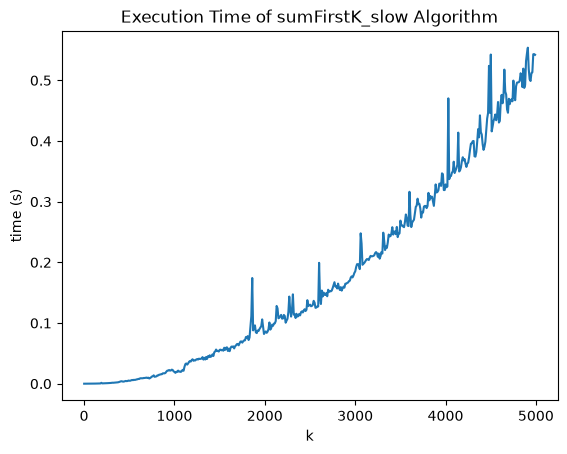

In [51]:
# Let's plot sumFirstK slow
sumFirstK_slow_times = benchmark_algo(sumFirstK_slow, test_cases)
df_slow = pd.DataFrame(sumFirstK_slow_times, columns = ["k", "time"])
df_slow['algo'] = "sumFirstK_slow"

sns.lineplot(data=df_slow, x="k", y="time")
plt.xlabel("k")
plt.ylabel("time (s)")
plt.title("Execution Time of sumFirstK_slow Algorithm")
plt.show()


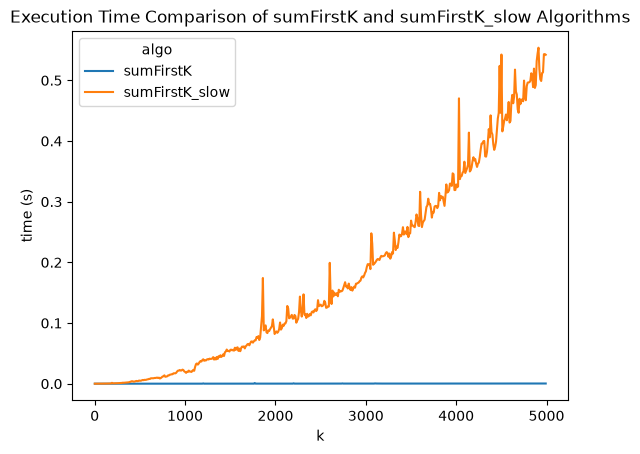

In [53]:
# Now, let's compare the performance of sumFirstK and sumFirstK_slow algorithms

df = pd.concat([df_base, df_slow], ignore_index=True)

sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (s)")
plt.title("Execution Time Comparison of sumFirstK and sumFirstK_slow Algorithms")
plt.show()

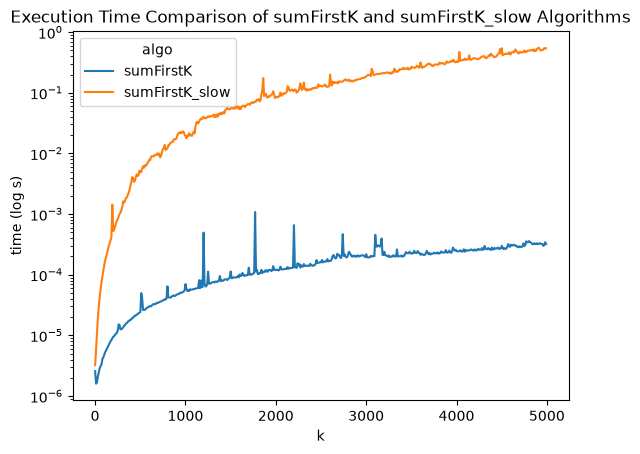

In [55]:
sns.lineplot(data=df, x="k", y="time", hue="algo")
plt.xlabel("k")
plt.ylabel("time (log s)")
plt.title("Execution Time Comparison of sumFirstK and sumFirstK_slow Algorithms")
plt.yscale('log')
plt.show()